![spreedsheet_finance](spreedsheet_finance.jpg)

Your project is centered around developing a reinforcement learning (RL) simulation for stock trading in Python. This initiative is spearheaded by Quantum Trading, a fictional but ambitious trading firm looking to leverage cutting-edge machine learning techniques to gain a competitive edge in the financial markets. Quantum Trading is a small but highly specialised team of financial analysts, data scientists, and software engineers who are passionate about transforming the way trading decisions are made.

In the fast-paced world of financial markets, staying ahead of the curve is crucial. Traditional trading strategies, while effective, often rely on historical data and predefined rules that may not adapt quickly to changing market conditions. Reinforcement learning, a subfield of machine learning where an agent learns to make decisions by interacting with an environment, offers a promising alternative. It allows the trading algorithms to learn and adapt in real-time, improving their performance as they gain more experience.

By engaging with this project, you will gain valuable insights into the dynamic world of algorithmic trading and enhance your skill set in data science, finance, and machine learning. Remember, the journey of learning and experimentation is as important as the results. Good luck, and may your trading algorithms be ever profitable!

## The Data
The provided data `AAPL.csv` contains historical prices for AAPL (the ticker symbol for Apple Inc) and you will be using this in your model. It has been loaded for you already in the sample code below and contains two columns, described below.

| Column | Description |
|--------|-------------|
|`Date`    | The date corresponding to the closing price              |
|`Close`   | The closing price of the security on the given date      |

_**Disclaimer: This project is for educational purposes only. It is not financial advice, and should not be understood or construed as, financial advice.**_

In [31]:
# Make sure to run this cell to use gymnasium gym-anytrading stable-baselines3
!pip install gymnasium gym-anytrading stable-baselines3

Defaulting to user installation because normal site-packages is not writeable


In [32]:
# Import required packages
# Note that gym-anytrading is a gym environment specific for trading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import gym_anytrading
from gym_anytrading.envs import Actions
from stable_baselines3 import PPO

# Load the data provided
data = pd.read_csv("AAPL.csv", parse_dates=True, index_col='Date')

# Set window size (lookback window), start and end index of data
window_size = 10
start_index = window_size
end_index = len(data)

# Create the environment using the pre-built 'stocks-v0', passing in the data loaded above
# window_size is how far the environment can look back at each step
# frame_bound is the bounding box of the environment, the size of our data
env = gym.make('stocks-v0', df=data, window_size=window_size, frame_bound=(start_index, end_index))
print("Observation Space:", env.observation_space)

# Initialise cash balance tracking and other variables
balance = 100000
balance_history = [balance]
shares_held = 0
action_stats = {Actions.Sell: 0, Actions.Buy: 0}
observation, info = env.reset(seed=2024)

Observation Space: Box(-10000000000.0, 10000000000.0, (10, 2), float32)


In [33]:
# Start coding here by training the PPO model

from stable_baselines3 import PPO

model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    seed=2024
)

model.learn(total_timesteps=10000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 2333 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.76e+03    |
|    ep_rew_mean          | 157         |
| time/                   |             |
|    fps                  | 710         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009119367 |
|    clip_fraction        | 0.00791     |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.685      |
|    explained_variance   | 0.0109      |
|    learning_rate        | 0.0003      |
|    loss               

In [34]:
# Reset environment and run the trained model, tracking trades
observation, info = env.reset(seed=2024)

balance = 100000
shares_held = 0
balance_history = [balance]
action_stats = {Actions.Sell: 0, Actions.Buy: 0}

trade_pct = 0.1   # fraction of current balance risked on each Buy
prices = []
buy_indices = []
sell_indices = []
done = False
step = 0
while not done:
    action, _states = model.predict(observation, deterministic=True)
    action = int(action)
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    current_price = env.unwrapped.prices[env.unwrapped._current_tick]
    prices.append(current_price)
    if action == Actions.Buy.value:
        action_stats[Actions.Buy] += 1
        trade_amount = balance * trade_pct
        if trade_amount > 0 and balance > 0:
            shares_bought = trade_amount / current_price
            shares_held += shares_bought
            balance -= trade_amount
            buy_indices.append(step)
    elif action == Actions.Sell.value:
        action_stats[Actions.Sell] += 1
        if shares_held > 0:
            balance += shares_held * current_price
            shares_held = 0
            sell_indices.append(step)
    balance_history.append(balance + shares_held * current_price)
    step += 1

if shares_held > 0:
    final_price = prices[-1]
    balance += shares_held * final_price
    shares_held = 0
    balance_history[-1] = balance

print("Final balance:", balance)
print("Action stats:", action_stats)

Final balance: 105672.44925172444
Action stats: {<Actions.Sell: 0>: 3626, <Actions.Buy: 1>: 137}


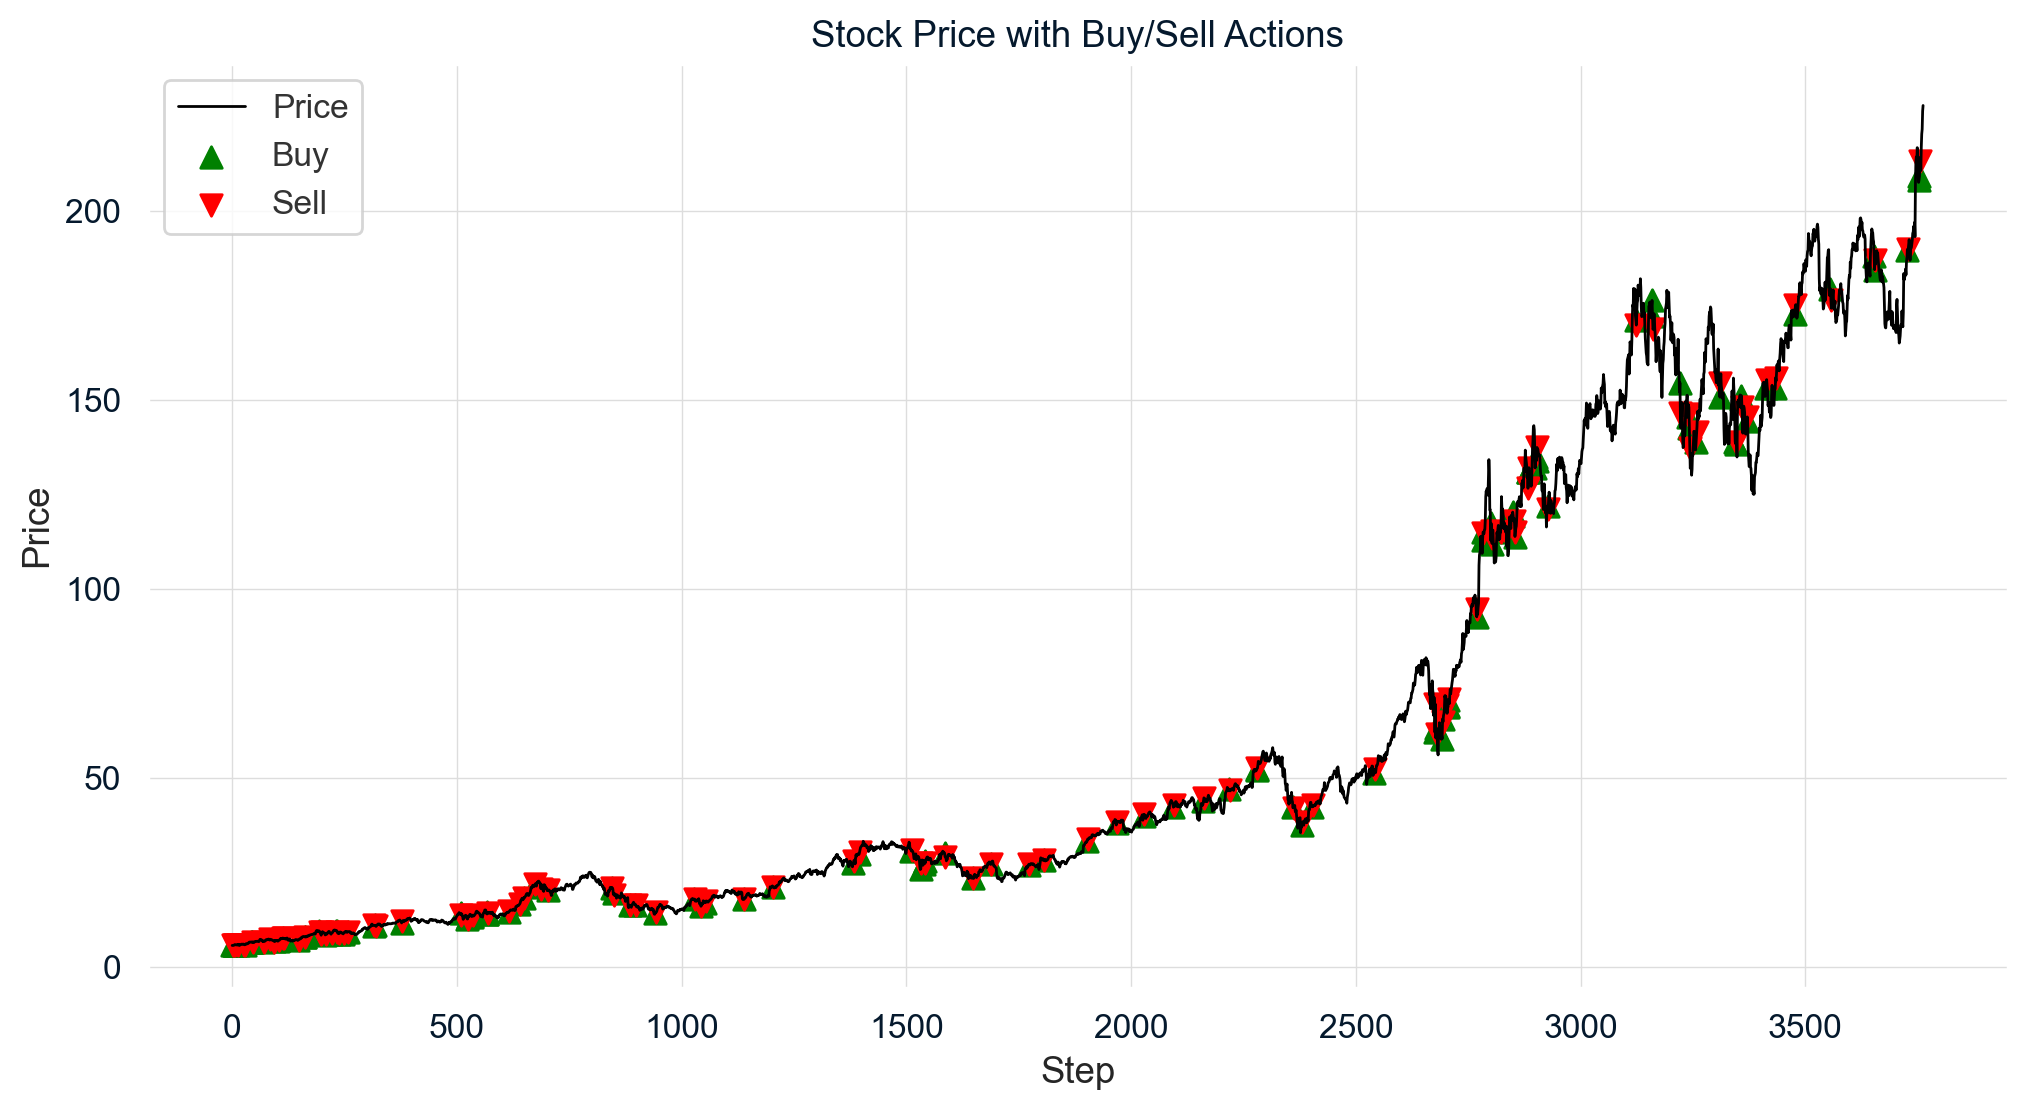

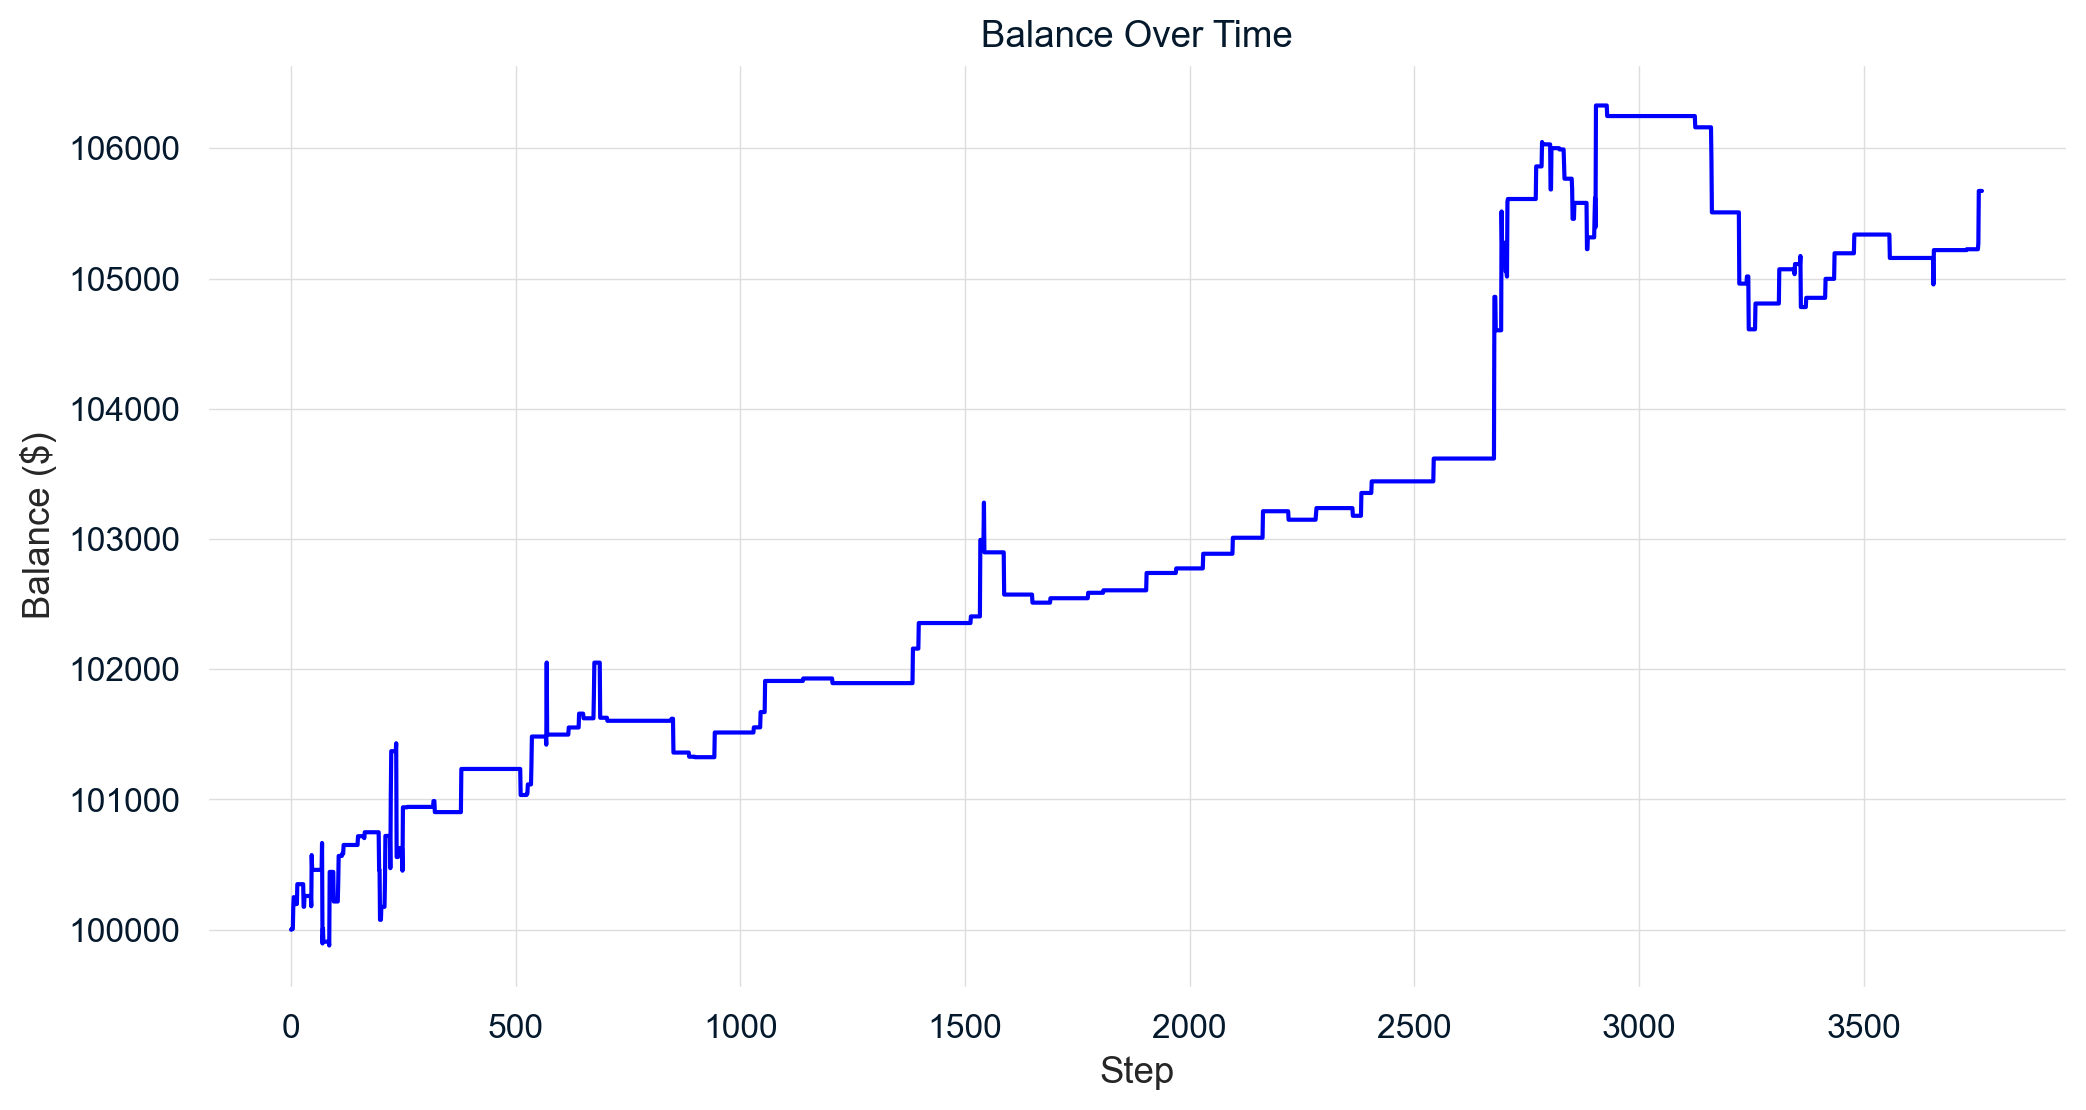

In [35]:
# Create your two charts below. Note, do not change the fig and ax variable names.

# Chart 1, a plot showing trading actions
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(prices, label='Price', color='black', linewidth=1)
ax.scatter(buy_indices, [prices[i] for i in buy_indices], marker='^', color='green', label='Buy', s=60)
ax.scatter(sell_indices, [prices[i] for i in sell_indices], marker='v', color='red', label='Sell', s=60)
ax.set_title('Stock Price with Buy/Sell Actions')
ax.set_xlabel('Step')
ax.set_ylabel('Price')
ax.legend()
plt.show()

# Chart 2, a plot of the balance_history over time

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(balance_history, color='blue')
ax.set_title('Balance Over Time')
ax.set_xlabel('Step')
ax.set_ylabel('Balance ($)')
plt.show()

                           Strategy
-------------------------  ----------
Start Period               2009-07-27
End Period                 2024-07-08
Risk-Free Rate             0.0%
Time in Market             3.0%

Cumulative Return          -68.11%
CAGR﹪                     -5.14%

Sharpe                     -1.1
Prob. Sharpe Ratio         0.0%
Smart Sharpe               -1.09
Sortino                    -1.28
Smart Sortino              -1.28
Sortino/√2                 -0.91
Smart Sortino/√2           -0.9
Omega                      0.27

Max Drawdown               -68.13%
Longest DD Days            5453
Volatility (ann.)          6.77%
Calmar                     -0.08
Skew                       -2.15
Kurtosis                   181.08

Expected Daily %           -0.03%
Expected Monthly %         -0.63%
Expected Yearly %          -6.89%
Kelly Criterion            -71.88%
Risk of Ruin               0.0%
Daily Value-at-Risk        -0.73%
Expected Shortfall (cVaR)  -0.73%

Max Consecutive 

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2009-08-04,2024-05-16,2024-07-08,5453,-68.130975,-66.969776


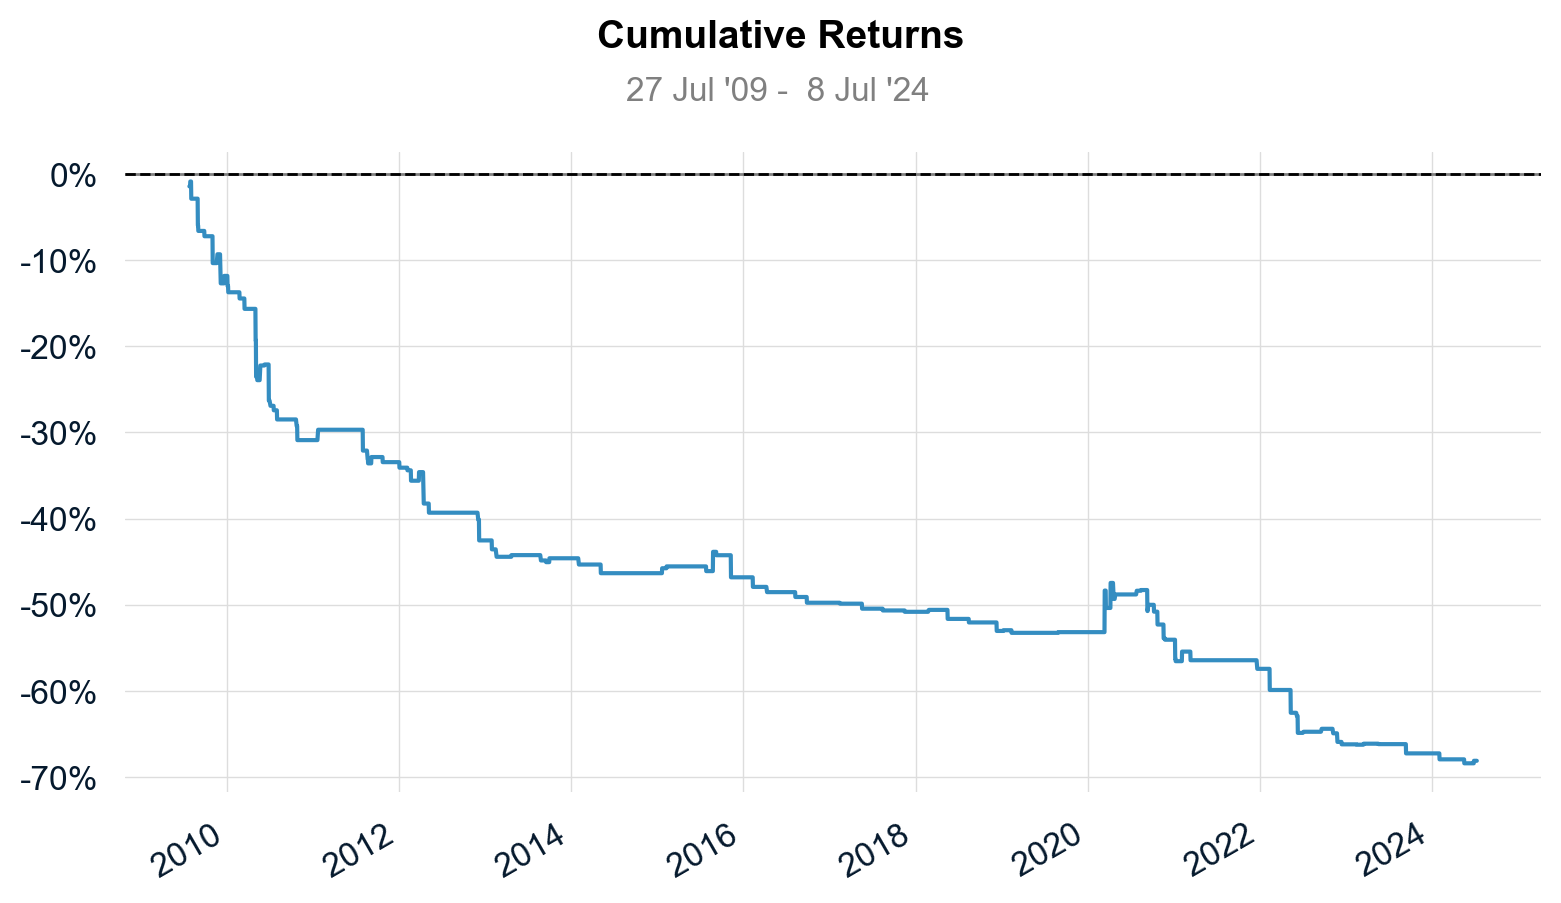

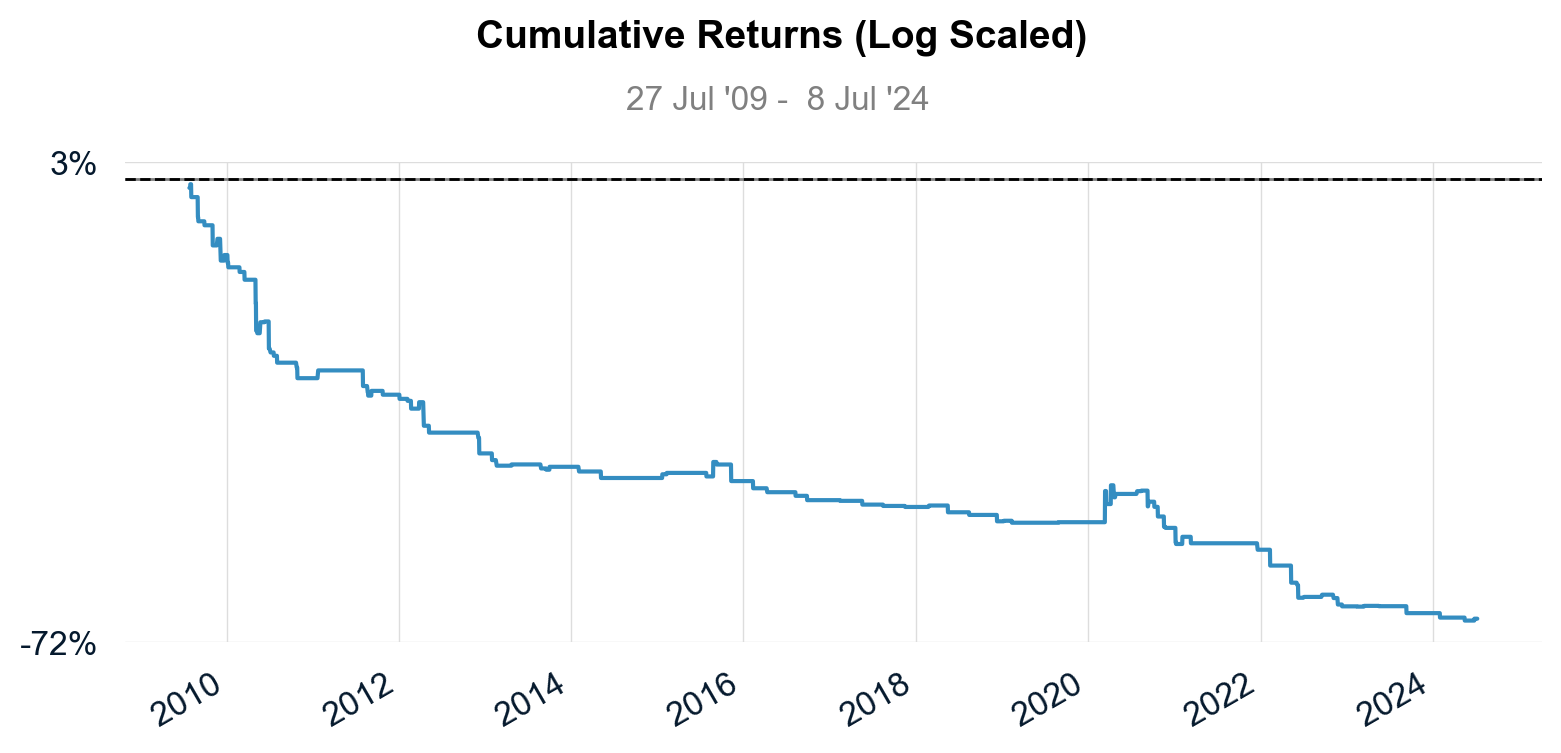

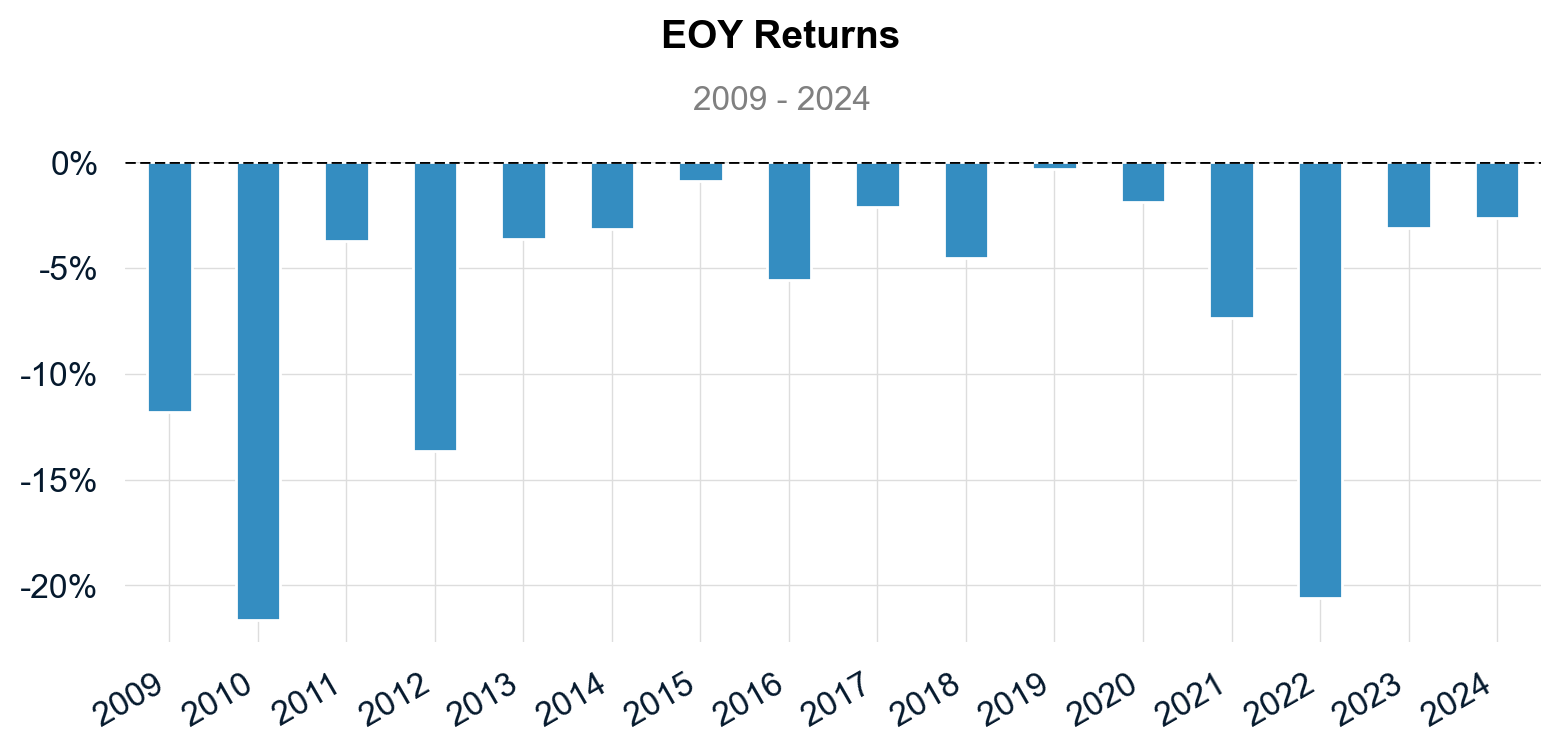

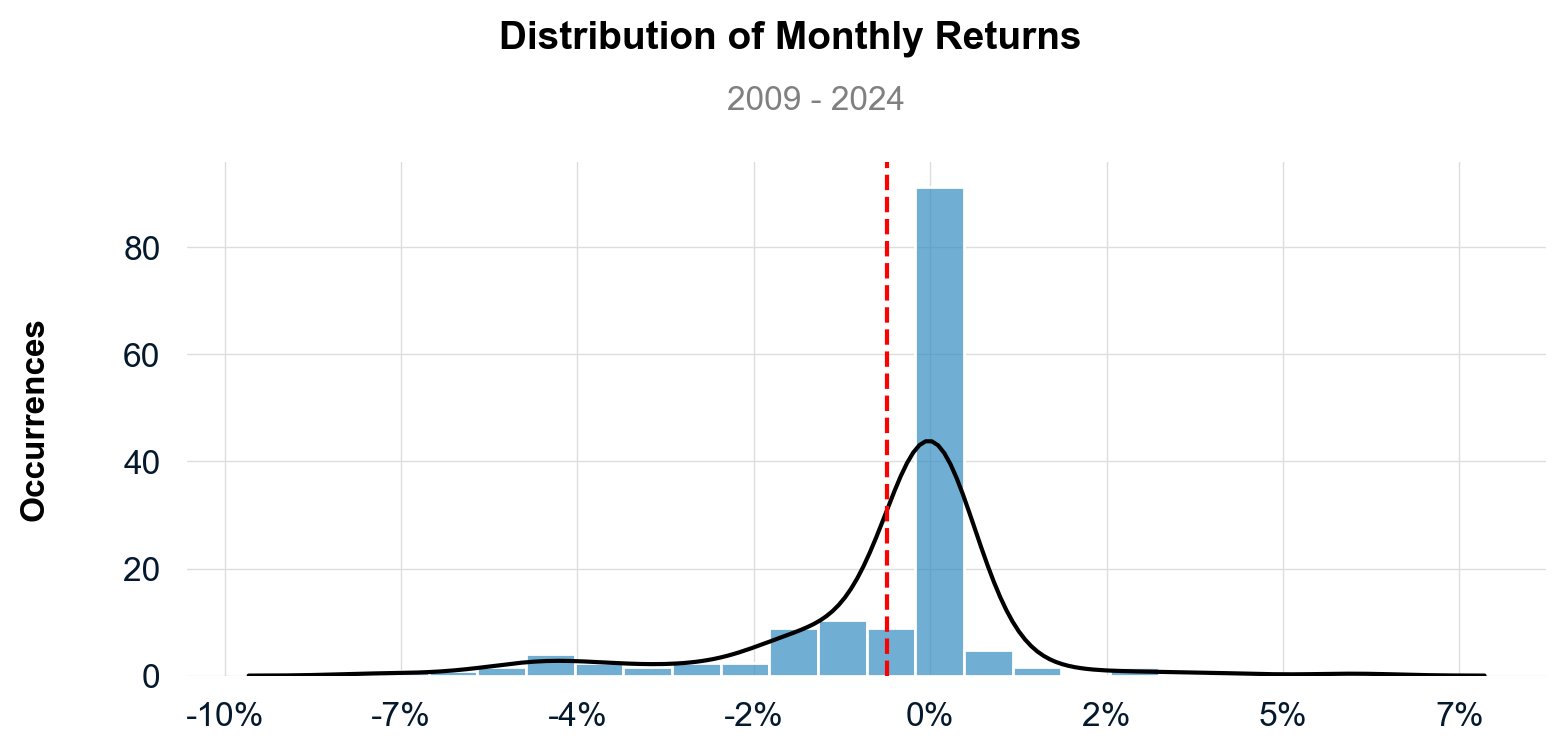

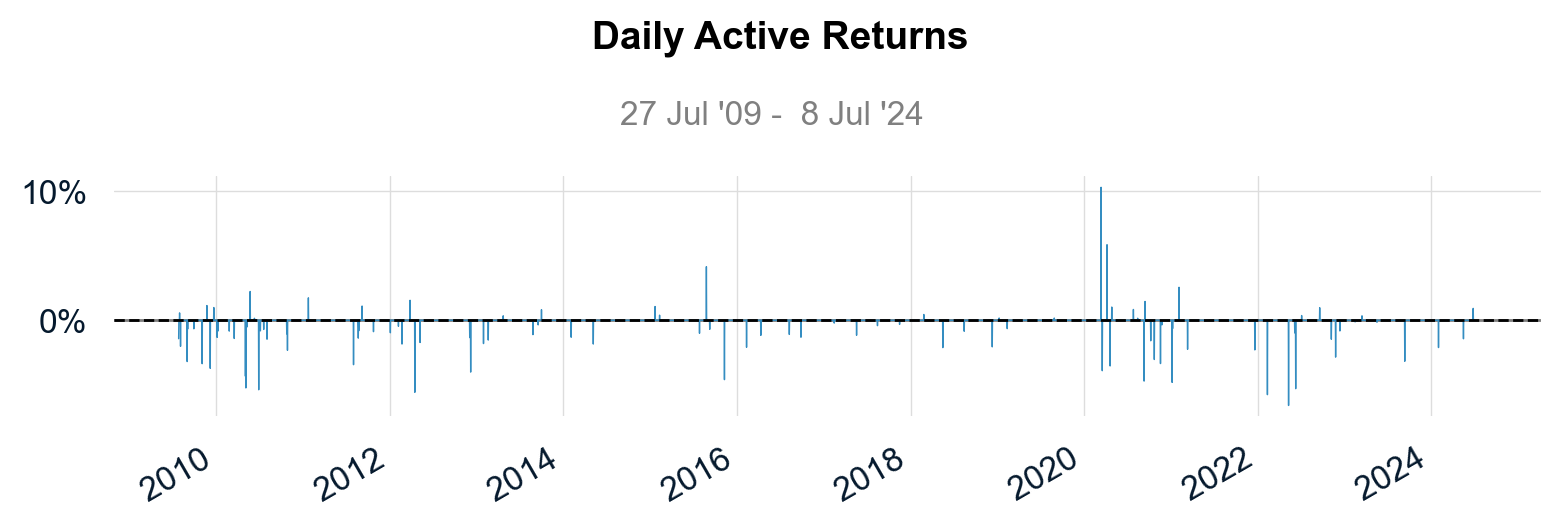

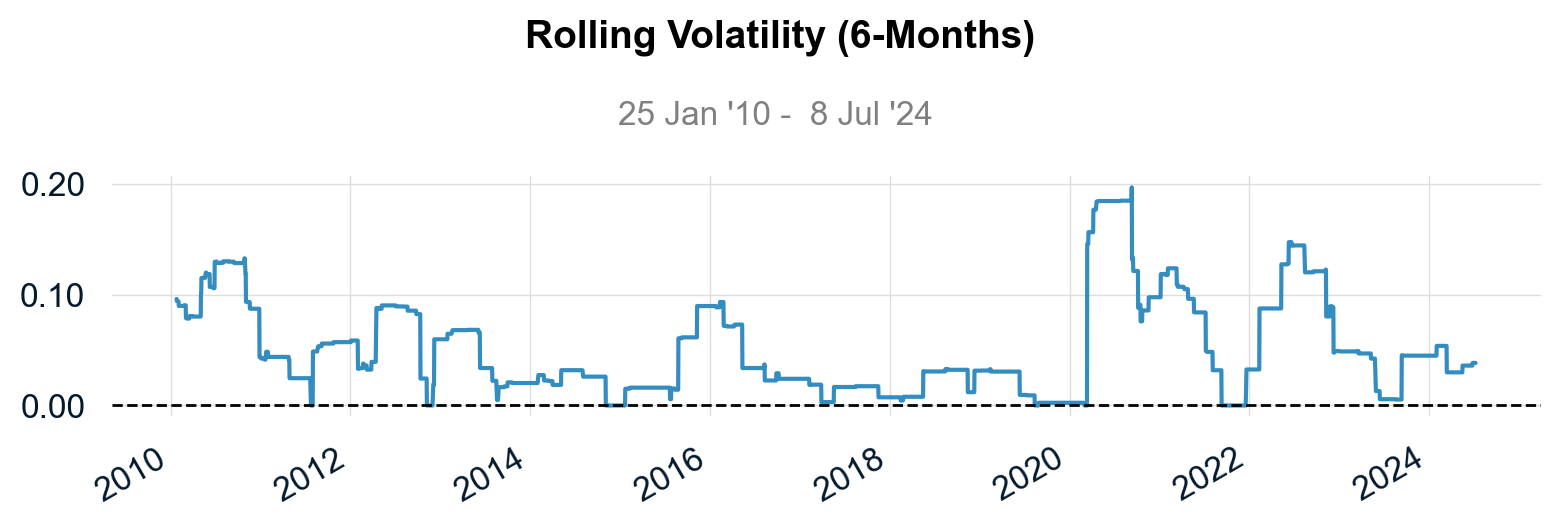

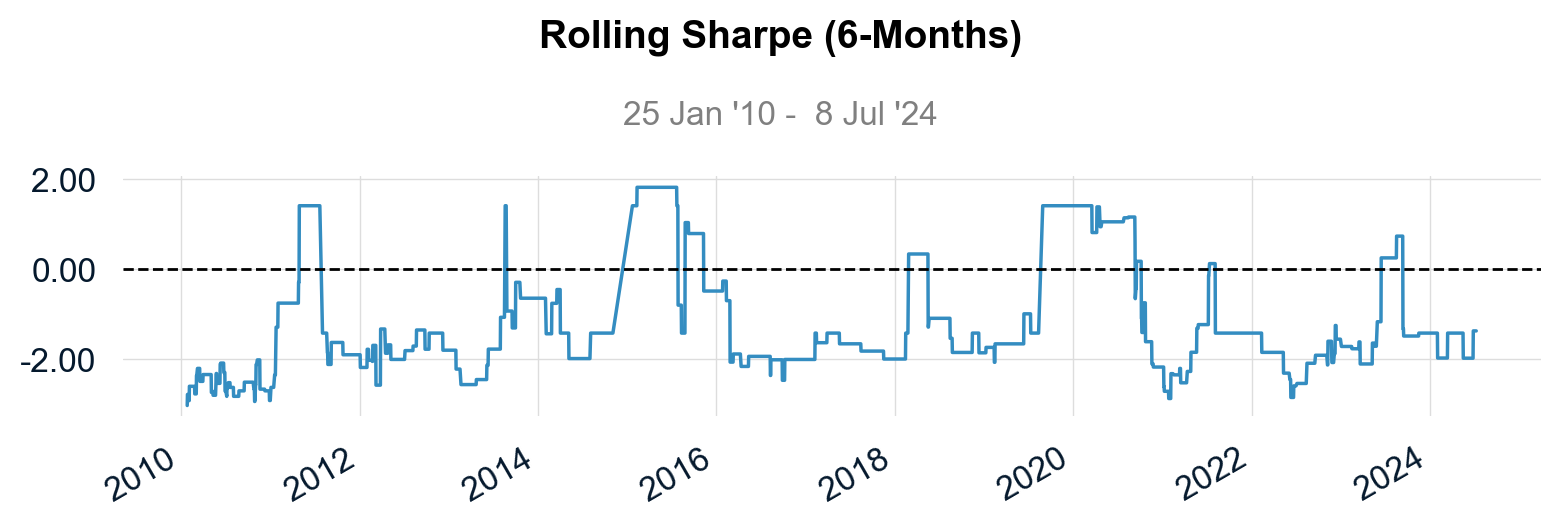

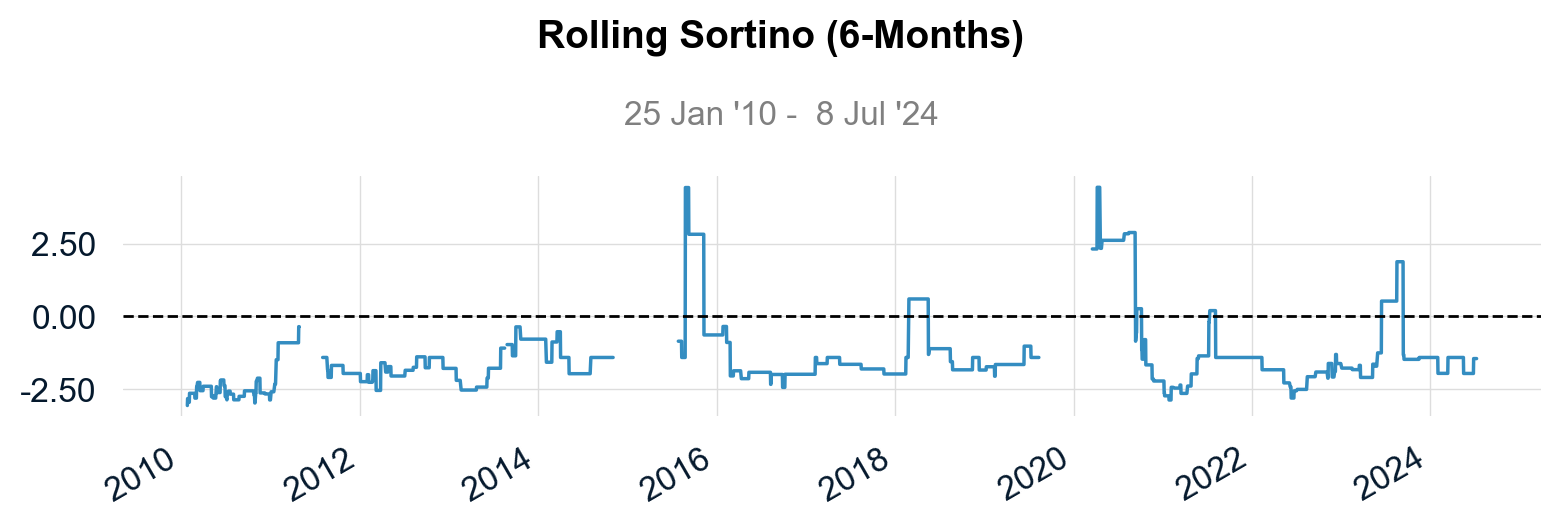

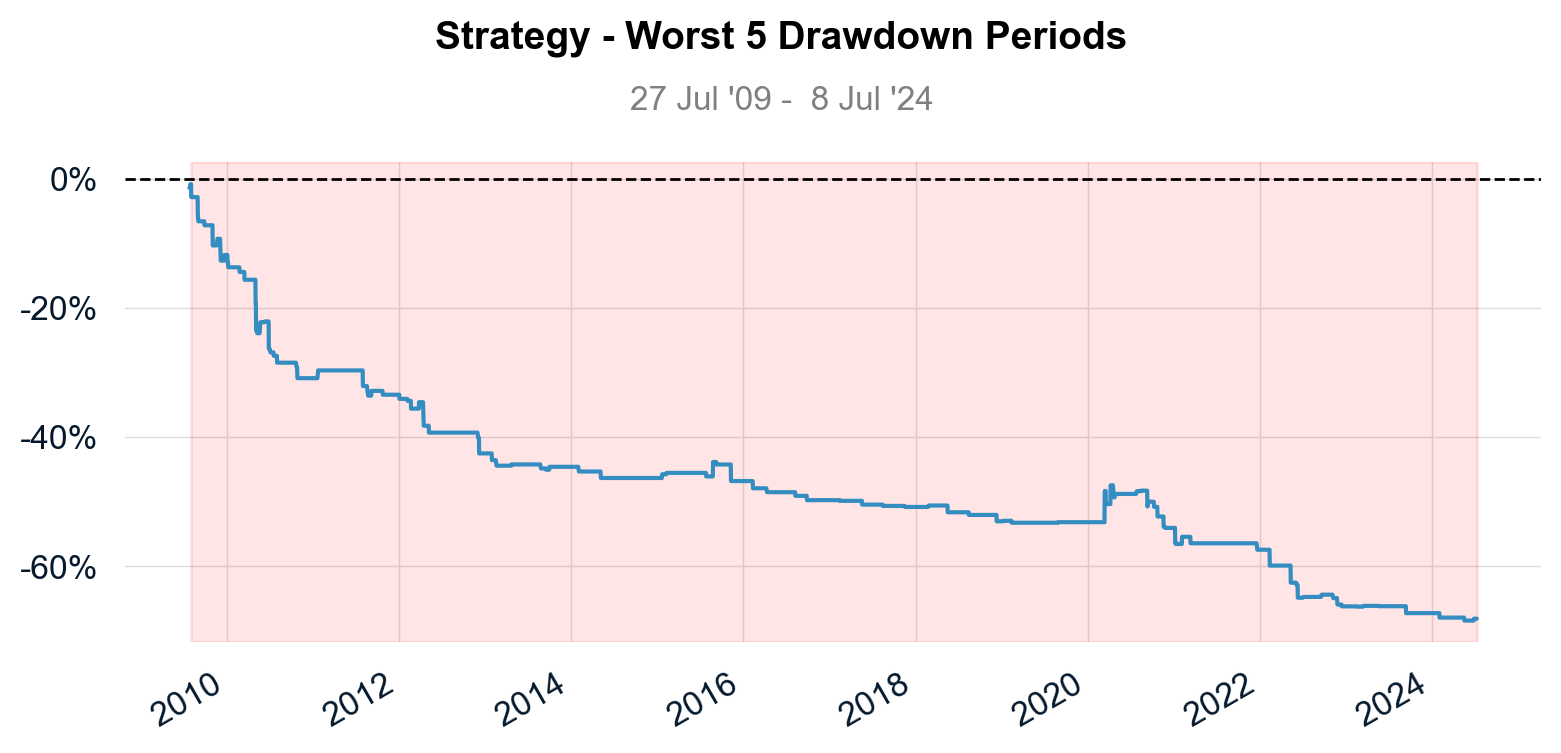

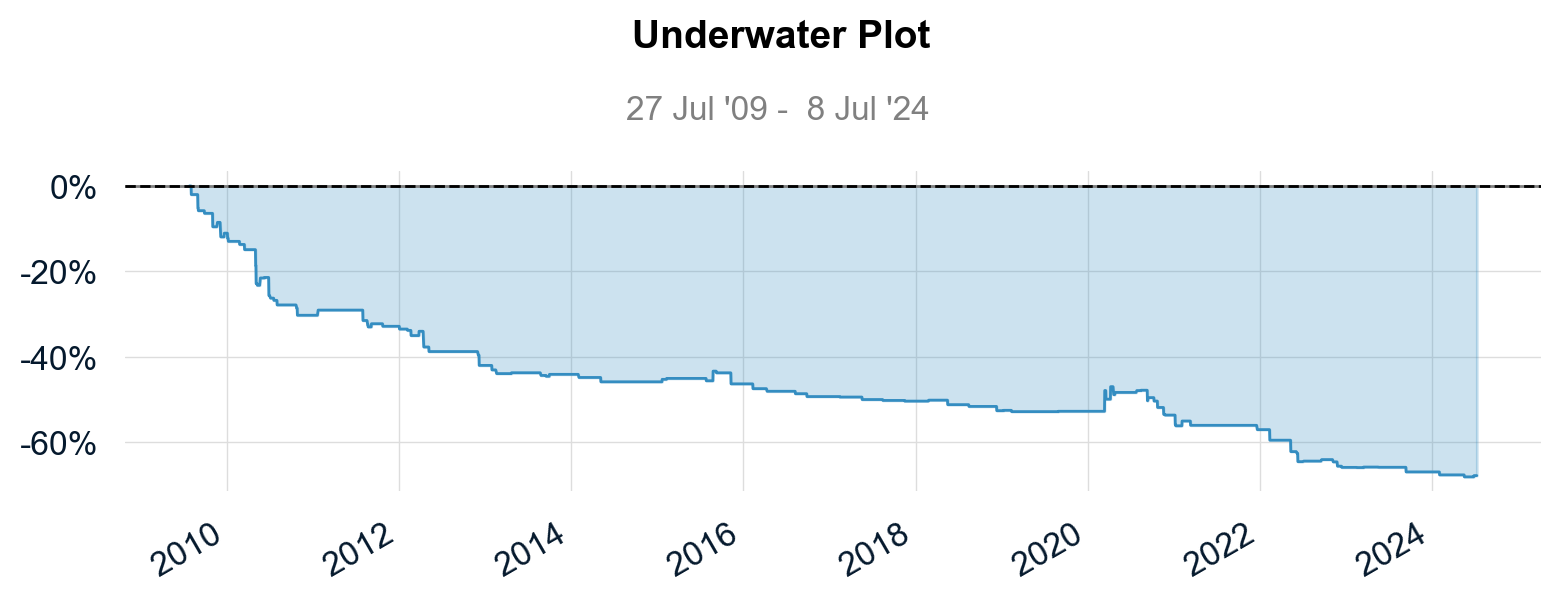

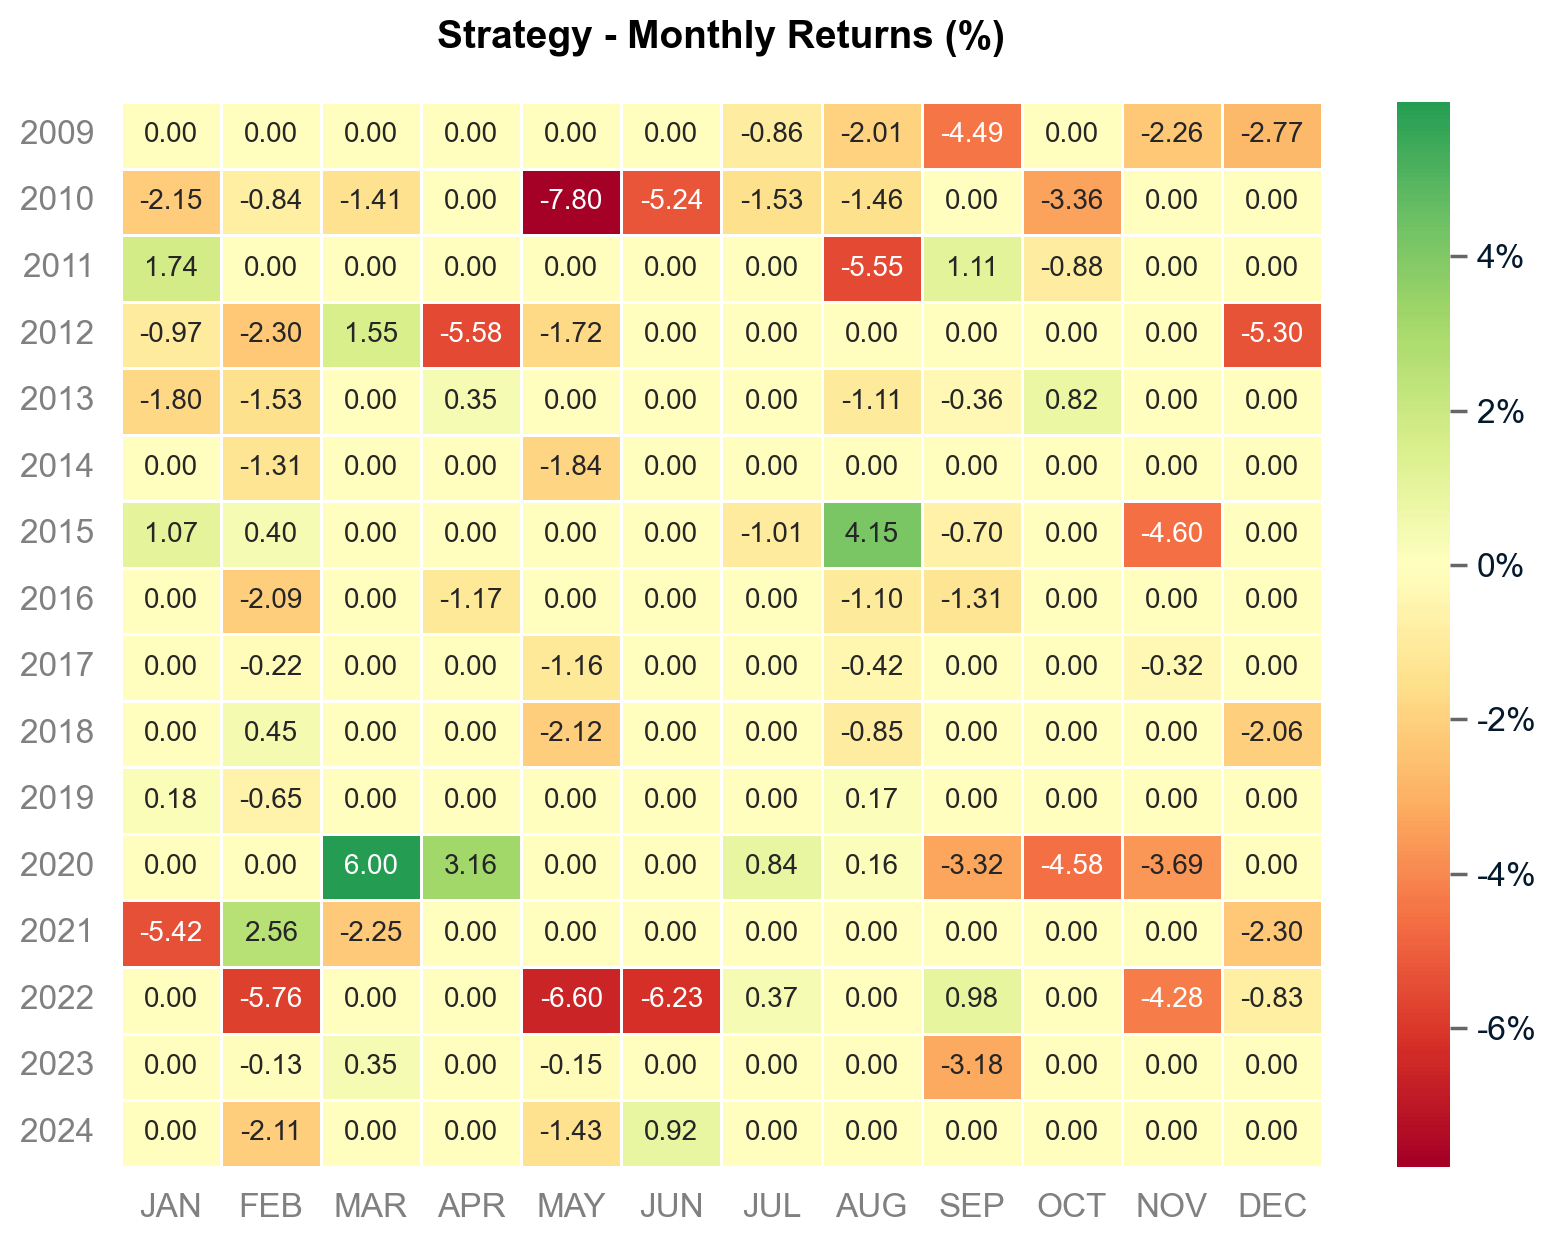

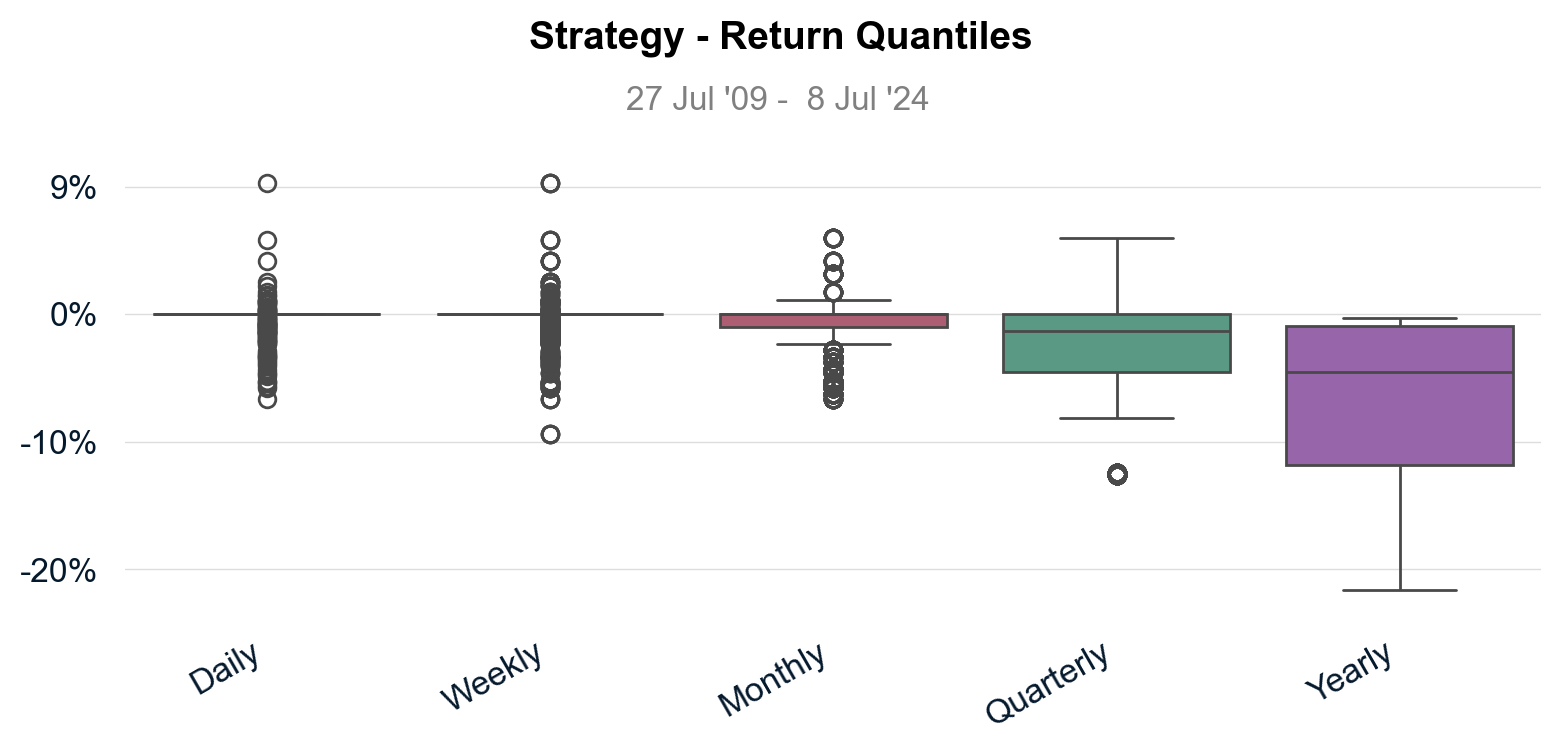

In [36]:
import quantstats as qs
qs.extend_pandas()

# Get the underlying (unwrapped) env to access its trade history
env_unwrapped = env.unwrapped

# Net worth as a Series, built from the environment's recorded total_profit,
# aligned to the corresponding dates in the original data
net_worth = pd.Series(
    env_unwrapped.history['total_profit'],
    index=data.index[-len(env_unwrapped.history['total_profit']):]
)

# Returns = percentage change in net worth
returns = net_worth.pct_change().iloc[1:]

# Full QuantStats tearsheet
qs.reports.full(returns)